In [1]:
import numpy as np  # arrays, linear algebra, RNG
import pandas as pd  # DataFrames/Series
import seaborn as sns  # plotting (clustermap)
import matplotlib.pyplot as plt  # Matplotlib backend
from sklearn.cluster import KMeans #Kmeans clustering 
from sklearn.preprocessing import StandardScaler #Standardisation
from sklearn.impute import KNNImputer #KNN imputation
import os, json, hashlib  # paths, JSON I/O, hashing
from pathlib import Path  # nicer filesystem paths
from __future__ import annotations
import pandas as pd
from sklearn.model_selection import train_test_split
import random

In [2]:
def _nearest_correlation_fast(C, eps=1e-10):
    """Project a matrix to a valid correlation matrix (PSD + renormalize)."""
    C = np.asarray(C)

    # Eigen-decompose symmetric C
    w, V = np.linalg.eigh(C, UPLO='L')

    # Clip tiny/negative eigenvalues (ensure PSD)
    w = np.maximum(w, eps)

    # Rebuild with clipped spectrum (avoid np.diag)
    C = (V * w) @ V.T

    # Scale to correlation (unit diagonal) with fewer temporaries
    d = np.sqrt(np.diag(C))
    inv_d = 1.0 / d
    C *= inv_d[:, None]
    C *= inv_d[None, :]

    np.fill_diagonal(C, 1.0)
    return C

In [3]:
def cap_corr_matrix_fast(C, max_corr_abs=0.95, eps=1e-10):
    """Uniformly shrink off-diagonals so max |corr| <= max_corr_abs,
    then project to a valid correlation matrix."""
    C = np.array(C, copy=True)
    n = C.shape[0]
    if n <= 1:
        return C

    iu = np.triu_indices(n, 1)
    max_off = float(np.max(np.abs(C[iu])))

    if max_off > max_corr_abs:
        scale = max_corr_abs / max_off
        C *= scale
        np.fill_diagonal(C, 1.0)

    return _nearest_correlation_fast(C, eps=eps)

In [4]:
def _sample_signed_factor_block_model_fast(
    p, n_clusters, *,
    within_abs_rho=0.6,
    neg_prob_within=0.5,
    size_dispersion=0.25,
    loading_mag_jitter=0.15,
    between_factor_rho_mean=0.0,
    between_factor_rho_sd=0.15,
    cross_loading_frac=0.0,
    cross_loading_scale=0.2,
    orphan_frac=0.0,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    K = int(n_clusters)

    # --- cluster sizes ---
    size_dispersion = float(np.clip(size_dispersion, 0.0, 1.0))
    alpha = 50.0 * (1.0 - size_dispersion) + 0.5

    probs = rng.dirichlet(np.full(K, alpha))
    sizes = rng.multinomial(p, probs)

    # ensure no empty clusters (usually a tiny loop because K is small)
    while (sizes == 0).any():
        a, b = sizes.argmin(), sizes.argmax()
        if sizes[b] <= 1:
            break
        sizes[a] += 1
        sizes[b] -= 1

    # faster membership construction
    membership = np.repeat(np.arange(K, dtype=int), sizes)
    rng.shuffle(membership)

    # --- orphans ---
    orphan_frac = float(np.clip(orphan_frac, 0.0, 1.0))
    korphan = int(p * orphan_frac)
    if korphan > 0:
        idx_orph = rng.choice(p, size=korphan, replace=False)
        membership[idx_orph] = -1

    # --- loadings ---
    L = np.zeros((p, K), dtype=float)

    non_orph_mask = membership >= 0
    rows = np.flatnonzero(non_orph_mask)
    cols = membership[non_orph_mask]

    # primary sign + magnitude (vectorised)
    neg_prob_within = float(np.clip(neg_prob_within, 0.0, 1.0))
    signs = np.where(rng.random(rows.size) < neg_prob_within, -1.0, 1.0)

    mags = rng.normal(1.0, loading_mag_jitter, size=rows.size)
    mags = np.maximum(0.05, mags)  # floor
    primary_vals = signs * mags

    L[rows, cols] = primary_vals

    # cross-loadings (vectorised)
    if cross_loading_frac > 0.0 and K > 1:
        cross_loading_frac = float(np.clip(cross_loading_frac, 0.0, 1.0))
        cross_mask = rng.random(rows.size) < cross_loading_frac
        if np.any(cross_mask):
            cr = rows[cross_mask]
            cc = cols[cross_mask]
            cmag = mags[cross_mask]

            # pick "other" uniformly from {0..K-1} \ {cc}
            other = rng.integers(0, K - 1, size=cr.size)
            other = other + (other >= cc)  # shift to skip current cluster

            sign2 = np.where(rng.random(cr.size) < 0.5, -1.0, 1.0)
            L[cr, other] = sign2 * cmag * cross_loading_scale

    # --- between-cluster factor correlation B ---
    B = np.eye(K, dtype=float)
    if K > 1:
        iu = np.triu_indices(K, 1)
        r = rng.normal(between_factor_rho_mean, between_factor_rho_sd, size=iu[0].size)
        r = np.clip(r, -1.0, 1.0)
        B[iu] = r
        B[(iu[1], iu[0])] = r

    B = _nearest_correlation_fast(B)  # or your original projector

    # --- noise ---
    # protect against bad inputs around 0
    within_abs_rho = float(np.clip(within_abs_rho, 1e-6, 1.0))
    noise_var = (1.0 - within_abs_rho) / within_abs_rho
    noise_std = float(np.sqrt(max(noise_var, 1e-8)))

    # --- primary sign record (vectorised) ---
    primary_sign = np.zeros(p, dtype=int)
    # for non-orphans, sign comes from the primary loading we set
    primary_sign[rows] = np.where(primary_vals > 0, 1, -1)

    # sizes list
    sizes_list = sizes.astype(int).tolist()

    return L, B, membership, sizes_list, noise_std, primary_sign


In [5]:
# ============================================================
# MAIN FUNCTION
# ============================================================
def simulate_high_dim_data_signed(
    n=100, p=200, n_clusters=5, *,
    input_data=None,
    n_sim=None, p_sim=None,

    # scratch-mode correlation knobs
    within_abs_rho=0.6,
    neg_prob_within=0.5,
    size_dispersion=0.25,
    loading_mag_jitter=0.15,
    between_factor_rho_mean=0.0,
    between_factor_rho_sd=0.15,
    cross_loading_frac=0.0,
    cross_loading_scale=0.2,
    orphan_frac=0.0,

    # global cap
    max_corr_abs=None,

    # sparse model
    n_causal=20,
    n_nonzero_betas=10,
    signal_to_noise=2.0,

    # new controls
    dependence="auto",            # "auto" | "correlated" | "independent"
    outcome="continuous",         # "continuous" | "binary"
    return_blueprint=False,       # default False as requested

    # mimic/extrapolation controls (when input_data is used)
    mimic_rank=50,
    mimic_loading_jitter=0.05,

    # ==========================================================
    # NEW: chunked generation controls (for huge n,p)
    # ==========================================================
    chunk_rows=200,               # tune (e.g., 100-300 for 16GB when p=200k)
    dtype=np.float32,             # float32 saves memory/disk
    out_path=None,                # if set, X is stored as a memmap on disk in independent mode

    random_state=42,
):
    rng = np.random.default_rng(random_state)

    # decide mode
    if dependence == "auto":
        dep_mode = "correlated" if input_data is not None else "correlated"
    else:
        dep_mode = dependence

    membership = cluster_sizes = primary_sign = None

    # ==========================================================
    # 1) BUILD X
    # ==========================================================
    if input_data is not None:
        # ---------- mimic-my-data with extrapolation ----------
        if isinstance(input_data, pd.DataFrame):
            df = input_data.select_dtypes(include=[np.number])
            if df.empty:
                raise ValueError("input_data contains no numeric columns.")
            df = df.fillna(df.mean())
            X_input = df.values
            cols = df.columns.tolist()
        else:
            X_input = np.asarray(input_data)
            if not np.issubdtype(X_input.dtype, np.number):
                raise ValueError("input_data must contain numeric values.")
            col_means = np.nanmean(X_input, axis=0)
            X_input = np.where(np.isnan(X_input), col_means, X_input)
            cols = [f"x{j+1}" for j in range(X_input.shape[1])]

        n_data, p_data = X_input.shape
        if n_data < 2 or p_data < 1:
            raise ValueError(f"input_data must have at least 2 rows and 1 column, got {n_data}×{p_data}.")
        if (X_input.std(axis=0) == 0).any():
            raise ValueError("input_data contains constant columns, which cannot be used.")

        n_sim = n_data if n_sim is None else int(n_sim)
        p_sim = p_data if p_sim is None else int(p_sim)
        if p_sim <= 0:
            raise ValueError("p_sim must be positive.")

        if dep_mode == "independent":
            # ---- chunked independent generation (disk-backed) ----
            if out_path is None:
                raise ValueError(
                    "For huge (n,p) with dependence='independent', set out_path to write X as a memmap "
                    "(avoids RAM MemoryError)."
                )

            X = np.lib.format.open_memmap(out_path, mode="w+", dtype=dtype, shape=(n_sim, p_sim))
            for i in range(0, n_sim, int(chunk_rows)):
                m = min(int(chunk_rows), n_sim - i)
                X[i:i+m, :] = rng.standard_normal((m, p_sim)).astype(dtype, copy=False)
            X.flush()

            if p_sim != p_data:
                cols = cols[:min(p_sim, p_data)] + [f"x{j+1}" for j in range(p_data, p_sim)]
        else:
            # Standardize input for correlation focus
            Xc = X_input - X_input.mean(axis=0, keepdims=True)
            Xs = Xc / (X_input.std(axis=0, ddof=0, keepdims=True) + 1e-12)

            # Empirical correlation
            C = np.corrcoef(Xs, rowvar=False)
            np.fill_diagonal(C, 1.0)

            # Optional cap on observed correlations
            if max_corr_abs is not None:
                C = cap_corr_matrix_fast(C, max_corr_abs=float(max_corr_abs))

            # Ensure PSD-ish
            C = _nearest_correlation_fast(C)

            # Low-rank extraction
            r = int(min(max(1, mimic_rank), p_data))
            w, V = np.linalg.eigh(C, UPLO="L")
            idx = np.argsort(w)[::-1]
            w = w[idx]
            V = V[:, idx]

            w_r = np.clip(w[:r], 1e-12, None)
            V_r = V[:, :r]

            # Loadings for observed features
            L0 = V_r * np.sqrt(w_r)  # (p_data, r)

            # Uniqueness for observed features
            u0 = 1.0 - np.sum(L0 * L0, axis=1)
            u0 = np.clip(u0, 1e-6, 1.0)

            # Extrapolate to p_sim
            if p_sim < p_data:
                idx_feat = rng.choice(p_data, size=p_sim, replace=False)
                L = L0[idx_feat]
                u = u0[idx_feat]
                cols = [cols[i] for i in idx_feat]
            elif p_sim == p_data:
                L = L0
                u = u0
            else:
                extra = p_sim - p_data
                take = rng.integers(0, p_data, size=extra)

                L_new = L0[take].copy()
                scale = np.std(L0, axis=0, ddof=0) + 1e-12
                L_new += rng.normal(0.0, mimic_loading_jitter, size=L_new.shape) * scale

                u_new = u0[take].copy()

                L = np.vstack([L0, L_new])
                u = np.concatenate([u0, u_new])

                cols = cols + [f"x{j+1}" for j in range(p_data, p_sim)]

            # Sample X via factor model (no big Cpop needed)
            F = rng.standard_normal((n_sim, L.shape[1]))   # n_sim × r
            E = rng.normal(0.0, np.sqrt(u)[None, :], size=(n_sim, p_sim))
            X = F @ L.T + E

            # Stabilize to unit variance numerically
            X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, ddof=0, keepdims=True) + 1e-12)

    else:
        # ---------- from-scratch ----------
        n_sim = int(n) if n_sim is None else int(n_sim)
        p_sim = int(p) if p_sim is None else int(p_sim)
        if p_sim <= 0:
            raise ValueError("p_sim must be positive.")
        cols = [f"x{j+1}" for j in range(p_sim)]

        if dep_mode == "independent":
            # ---- chunked independent generation (disk-backed) ----
            if out_path is None:
                raise ValueError(
                    "For huge (n,p) with dependence='independent', set out_path to write X as a memmap "
                    "(avoids RAM MemoryError)."
                )

            X = np.lib.format.open_memmap(out_path, mode="w+", dtype=dtype, shape=(n_sim, p_sim))
            for i in range(0, n_sim, int(chunk_rows)):
                m = min(int(chunk_rows), n_sim - i)
                X[i:i+m, :] = rng.standard_normal((m, p_sim)).astype(dtype, copy=False)
            X.flush()
        else:
            L, B, membership, cluster_sizes, noise_std, primary_sign = _sample_signed_factor_block_model_fast(
                p_sim, n_clusters,
                within_abs_rho=within_abs_rho,
                neg_prob_within=neg_prob_within,
                size_dispersion=size_dispersion,
                loading_mag_jitter=loading_mag_jitter,
                between_factor_rho_mean=between_factor_rho_mean,
                between_factor_rho_sd=between_factor_rho_sd,
                cross_loading_frac=cross_loading_frac,
                cross_loading_scale=cross_loading_scale,
                orphan_frac=orphan_frac,
                random_state=random_state,
            )

            # Ensure B usable
            try:
                cholB = np.linalg.cholesky(B)
            except np.linalg.LinAlgError:
                B = _nearest_correlation_fast(B)
                cholB = np.linalg.cholesky(B)

            K = B.shape[0]
            F = rng.standard_normal((n_sim, K)) @ cholB.T
            E = rng.normal(0.0, noise_std, size=(n_sim, p_sim))
            X = F @ L.T + E

            # Scale to unit variance using only diag(S)
            LB = L @ B
            diag_S = np.sum(LB * L, axis=1) + noise_std**2
            inv_sd = 1.0 / np.sqrt(np.maximum(diag_S, 1e-12))
            X *= inv_sd[None, :]

            # Optional strict-ish cap for scratch mode:
            # Enforcing a global cap exactly would require building Cpop (slow),
            # so we do nothing here besides recording it in meta.
            # If you still want strict enforcement, we can add a hybrid check.

    # ==========================================================
    # 2) Sparse true model
    # ==========================================================
    if n_causal > p_sim:
        raise ValueError("n_causal must be <= p_sim.")
    if n_nonzero_betas > n_causal:
        raise ValueError("n_nonzero_betas must be <= n_causal.")

    causal_idx = rng.choice(p_sim, size=n_causal, replace=False).astype(int)
    nonzero_idx = rng.choice(causal_idx, size=n_nonzero_betas, replace=False).astype(int)

    beta = np.zeros(p_sim, dtype=np.float32)
    beta[nonzero_idx] = rng.normal(0.0, 1.0, size=n_nonzero_betas).astype(np.float32) #Change here for large effect size

    # ==========================================================
    # 2.5) linpred computed in chunks (works for memmap & ndarray)
    # ==========================================================
    linpred = np.empty(n_sim, dtype=np.float32)
    for i in range(0, n_sim, int(chunk_rows)):
        m = min(int(chunk_rows), n_sim - i)
        linpred[i:i+m] = (X[i:i+m, :] @ beta).astype(np.float32)

    # ==========================================================
    # 3) Outcome generation
    # ==========================================================
    if outcome == "continuous":
        denom = signal_to_noise if signal_to_noise > 0 else 1.0
        noise_std_y = float(np.std(linpred) / denom)
        y = linpred + rng.normal(0.0, noise_std_y, size=n_sim).astype(np.float32)
    else:
        probs = 1.0 / (1.0 + np.exp(-linpred))
        y = rng.binomial(1, probs, size=n_sim).astype(np.float32)

    # ==========================================================
    # 4) Wrap outputs
    # ==========================================================
    # IMPORTANT: do NOT build a DataFrame for huge memmap X
    X_is_memmap = isinstance(X, np.memmap)
    X_df = None if X_is_memmap else pd.DataFrame(X, columns=cols)

    y_s = pd.Series(y, name="y")
    beta_s = pd.Series(beta, index=cols, name="beta")

    meta = dict(
        n=n_sim,
        p=p_sim,
        dependence=dep_mode,
        outcome=outcome,
        max_corr_abs=float(max_corr_abs) if max_corr_abs is not None else None,

        # NEW: chunk/dtype/out_path info
        chunk_rows=int(chunk_rows),
        dtype=str(np.dtype(dtype)),
        out_path=out_path if X_is_memmap else None,

        # scratch-only descriptors
        n_clusters=int(n_clusters) if input_data is None and dep_mode == "correlated" else None,
        within_abs_rho=float(within_abs_rho) if input_data is None and dep_mode == "correlated" else None,
        neg_prob_within=float(neg_prob_within) if input_data is None and dep_mode == "correlated" else None,
        size_dispersion=float(size_dispersion) if input_data is None and dep_mode == "correlated" else None,
        loading_mag_jitter=float(loading_mag_jitter) if input_data is None and dep_mode == "correlated" else None,
        between_factor_rho_mean=float(between_factor_rho_mean) if input_data is None and dep_mode == "correlated" else None,
        between_factor_rho_sd=float(between_factor_rho_sd) if input_data is None and dep_mode == "correlated" else None,
        cross_loading_frac=float(cross_loading_frac) if input_data is None and dep_mode == "correlated" else None,
        cross_loading_scale=float(cross_loading_scale) if input_data is None and dep_mode == "correlated" else None,
        orphan_frac=float(orphan_frac) if input_data is None and dep_mode == "correlated" else None,

        # mimic-only descriptors
        mimic_rank=int(mimic_rank) if input_data is not None and dep_mode == "correlated" else None,
        mimic_loading_jitter=float(mimic_loading_jitter) if input_data is not None and dep_mode == "correlated" else None,

        # model params
        n_causal=int(n_causal),
        n_nonzero_betas=int(n_nonzero_betas),
        signal_to_noise=float(signal_to_noise) if outcome == "continuous" else None,
    )

    if return_blueprint and membership is not None:
        meta["cluster_sizes"] = tuple(int(s) for s in cluster_sizes) if cluster_sizes is not None else None
        meta["membership"] = membership.astype(int).tolist()
        meta["primary_sign"] = primary_sign.astype(int).tolist()

    # Return X as DataFrame when small; for huge independent mode return memmap + path
    return {
        "X": X_df if X_df is not None else X,   # X is memmap if huge
        "X_path": out_path if X_is_memmap else None,
        "y": y_s,
        "beta": beta_s,
        "meta": meta,
    }

In [6]:
out1 = simulate_high_dim_data_signed(
    n=50, p=300, n_clusters=3,
    neg_prob_within=0.5,
    size_dispersion=0.75,
    loading_mag_jitter=0.75,
    between_factor_rho_mean=0.0,
    between_factor_rho_sd=0.15,
    cross_loading_frac=0.75,
    cross_loading_scale=0.55,
    within_abs_rho=0.70,
    max_corr_abs=0.70,
    dependence="correlated",     # explicit
    outcome="continuous",        # default anyway
    return_blueprint=True,       # if you want membership/signs in meta
    random_state=2025
)

X1 = out1["X"]
meta1 = out1["meta"]

In [7]:
X1_corr = X1.corr()

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


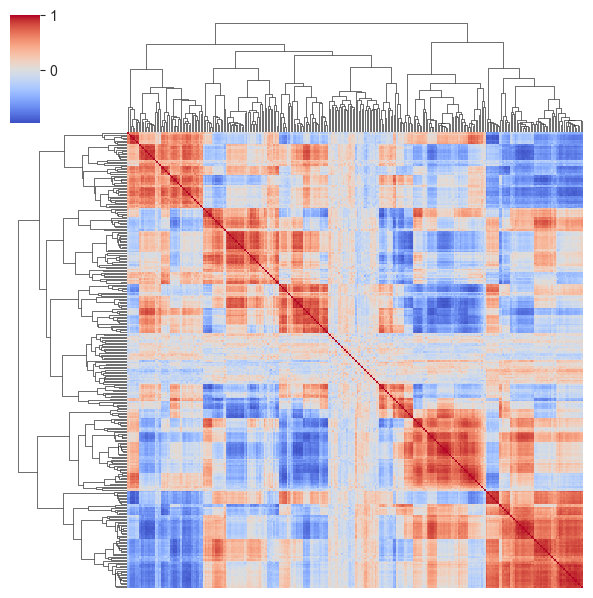

In [8]:
sns.clustermap(X1_corr, cmap="coolwarm", center=0.0, figsize=(6,6), xticklabels=False, yticklabels=False)
plt.show()

In [9]:
out2 = simulate_high_dim_data_signed(
    n=50, p=3000, n_clusters=3,
    neg_prob_within=0.5,
    size_dispersion=0.75,
    loading_mag_jitter=0.75,
    between_factor_rho_mean=0.5,
    between_factor_rho_sd=0.15,
    cross_loading_frac=0.5,
    cross_loading_scale=0.5,
    within_abs_rho=0.50,
    max_corr_abs=0.50,
    dependence="correlated",     # explicit
    outcome="continuous",        # default anyway
    return_blueprint=True,
    random_state=2025
)
X2 = out2["X"]

In [10]:
X2_corr = X2.corr()

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


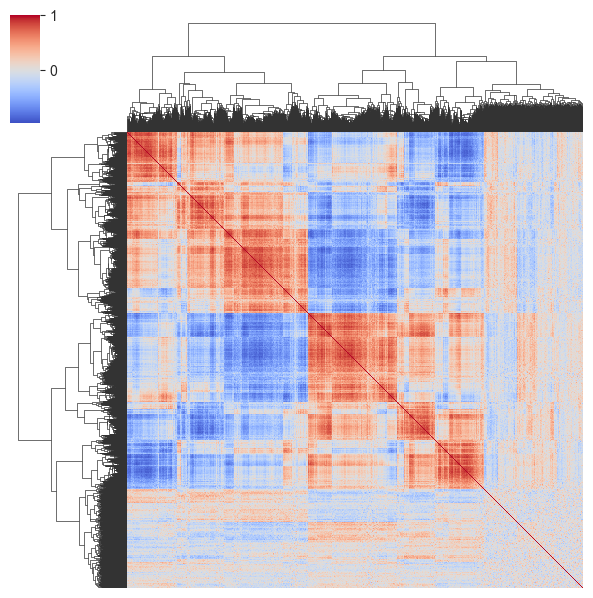

In [11]:
sns.clustermap(X2_corr, cmap="coolwarm", center=0.0, figsize=(6,6), xticklabels=False, yticklabels=False)
plt.show()

In [6]:
## set the seed
random.seed(1)

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/")

for i in range(10):
    res = simulate_high_dim_data_signed(
    n=1_000, p=1_000,
    dependence="independent",
    out_path="X_10k_200k_f32.npy",
    dtype=np.float32,
    chunk_rows=200,
    n_causal=200,          # must be >= 200
    n_nonzero_betas=200,
    random_state = i
    )
    # Daten aus res laden
    X = res['X']
    y = res['y']
    beta = res['beta']

    # 80/20 Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # In CSVs speichern
    pd.DataFrame(X_train).to_csv(f"{base}/X_train{i+1}.csv", index=False)
    print(f"{base}/X_train{i+1}.csv done")
    pd.DataFrame(X_test).to_csv(f"{base}/X_test{i+1}.csv", index=False)
    print(f"{base}/X_test{i+1}.csv done")
    pd.DataFrame(y_train).to_csv(f"{base}/y_train{i+1}.csv", index=False)
    print(f"{base}/y_train{i+1}.csv done")
    pd.DataFrame(y_test).to_csv(f"{base}/y_test{i+1}.csv", index=False)
    print(f"{base}/y_test{i+1}.csv done")
    pd.DataFrame(beta).to_csv(f"{base}/beta{i+1}.csv", index=False)
    print(f"{base}/beta{i+1}.csv done")

print("Train- und Testdaten wurden gespeichert.")

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/X_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/X_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/y_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/y_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p1000_n1000/beta1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/St

In [7]:
## set the seed
random.seed(1)

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/")

for i in range(10):
    res = simulate_high_dim_data_signed(
    n=5_000, p=5_000,
    dependence="independent",
    out_path="X_10k_200k_f32.npy",
    dtype=np.float32,
    chunk_rows=200,
    n_causal=500,          # must be >= 200
    n_nonzero_betas=500,
    random_state = i
    )
    # Daten aus res laden
    X = res['X']
    y = res['y']
    beta = res['beta']

    # 80/20 Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=44
    )

    # In CSVs speichern
    pd.DataFrame(X_train).to_csv(f"{base}/X_train{i+1}.csv", index=False)
    print(f"{base}/X_train{i+1}.csv done")
    pd.DataFrame(X_test).to_csv(f"{base}/X_test{i+1}.csv", index=False)
    print(f"{base}/X_test{i+1}.csv done")
    pd.DataFrame(y_train).to_csv(f"{base}/y_train{i+1}.csv", index=False)
    print(f"{base}/y_train{i+1}.csv done")
    pd.DataFrame(y_test).to_csv(f"{base}/y_test{i+1}.csv", index=False)
    print(f"{base}/y_test{i+1}.csv done")
    pd.DataFrame(beta).to_csv(f"{base}/beta{i+1}.csv", index=False)
    print(f"{base}/beta{i+1}.csv done")

print("Train- und Testdaten wurden gespeichert.")

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/X_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/X_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/y_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/y_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p5000_n5000/beta1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/St

In [ ]:
## set the seed
random.seed(1)
base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/")
#base = Path("/content/drive/MyDrive/Simulation_Data/p10000_n10000/")
for i in range(10):
    res = simulate_high_dim_data_signed(
    n=10_000, p=10_000,
    dependence="independent",
    out_path="X_10k_200k_f32.npy",
    dtype=np.float32,
    chunk_rows=200,
    n_causal=500,          # must be >= 200
    n_nonzero_betas=500,
    random_state = i
    )
    # Daten aus res laden
    X = res['X']
    y = res['y']
    beta = res['beta']

    # 80/20 Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=44
    )

    # In CSVs speichern
    pd.DataFrame(X_train).to_csv(f"{base}/X_train{i+1}.csv", index=False)
    print(f"{base}/X_train{i+1}.csv done")
    pd.DataFrame(X_test).to_csv(f"{base}/X_test{i+1}.csv", index=False)
    print(f"{base}/X_test{i+1}.csv done")
    pd.DataFrame(y_train).to_csv(f"{base}/y_train{i+1}.csv", index=False)
    print(f"{base}/y_train{i+1}.csv done")
    pd.DataFrame(y_test).to_csv(f"{base}/y_test{i+1}.csv", index=False)
    print(f"{base}/y_test{i+1}.csv done")
    pd.DataFrame(beta).to_csv(f"{base}/beta{i+1}.csv", index=False)
    print(f"{base}/beta{i+1}.csv done")

print("Train- und Testdaten wurden gespeichert.")

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/X_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/X_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/y_train1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/y_test1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data2/p10000_n10000/beta1.csv done
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Do